In [12]:
import qiskit
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from numpy import sqrt

X = Operator([[0, 1], [1, 0]])
Y = Operator([[0, -1.0j], [1.0j, 0]])
Z = Operator([[1, 0], [0, -1]])
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])

v = Statevector([1, 0])

In [13]:
v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(Z)

display(v.draw("text"))
display(v.draw("latex"))

[ 0.85355339+0.35355339j,-0.35355339+0.14644661j]

<IPython.core.display.Latex object>

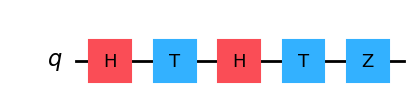

In [14]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.t(0)
circuit.z(0)

display(circuit.draw(output='mpl'))

In [15]:
ket0 = Statevector([1, 0])
v = ket0.evolve(circuit)
v.draw("text")

[ 0.85355339+0.35355339j,-0.35355339+0.14644661j]

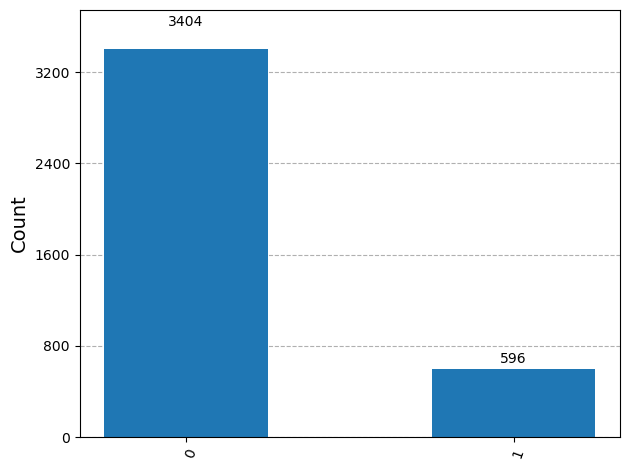

In [16]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(4000)
plot_histogram(statistics)

In [17]:
# Define R = H * S * H
R = H.compose(S).compose(H)

# Apply R twice
R_squared = R.compose(R)

# Verify that R² = X (NOT gate)
print("R² operator:")
print(R_squared)
print("\nX (NOT) operator:")
print(X)
print("\nAre they equal?", R_squared.equiv(X))

# Alternative verification: Show that R²|0⟩ = |1⟩ and R²|1⟩ = |0⟩
ket0 = Statevector([1, 0])
ket1 = Statevector([0, 1])

result0 = ket0.evolve(R).evolve(R)
result1 = ket1.evolve(R).evolve(R)

print("\nR²|0⟩ =", result0.draw('text'))
print("R²|1⟩ =", result1.draw('text'))

R² operator:
Operator([[-1.23259516e-32-1.23259516e-32j,
            1.00000000e+00+1.23259516e-32j],
          [ 1.00000000e+00-1.23259516e-32j,
           -1.23259516e-32+1.23259516e-32j]],
         input_dims=(2,), output_dims=(2,))

X (NOT) operator:
Operator([[0.+0.j, 1.+0.j],
          [1.+0.j, 0.+0.j]],
         input_dims=(2,), output_dims=(2,))

Are they equal? True

R²|0⟩ = [-1.23259516e-32-1.23259516e-32j, 1.00000000e+00+1.23259516e-32j]
R²|1⟩ = [ 1.00000000e+00-1.23259516e-32j,-1.23259516e-32+1.23259516e-32j]
